In [ ]:
from src.data_utils import load_openrouter_models, load_whitelist, normalize_slug_advanced
from src.viz_utils import plot_clusters, interactive_scatter
import pandas as pd


In [2]:
url = "https://openrouter.ai/api/v1/models"

In [3]:
request = requests.get(url)
openrouter_data = request.json()
model_list = openrouter_data['data']

In [4]:
print(len(model_list))

367


In [5]:
print(json.dumps(model_list[0], indent=2))

{
  "id": "google/gemini-3.1-flash-lite",
  "canonical_slug": "google/gemini-3.1-flash-lite-20260507",
  "hugging_face_id": null,
  "name": "Google: Gemini 3.1 Flash Lite",
  "created": 1778168828,
  "description": "Gemini 3.1 Flash Lite is Google\u2019s GA high-efficiency multimodal model optimized for low-latency, high-volume workloads. It supports text, image, video, audio, and PDF inputs, and is designed for lightweight agentic...",
  "context_length": 1048576,
  "architecture": {
    "modality": "text+image+file+audio+video->text",
    "input_modalities": [
      "text",
      "image",
      "video",
      "file",
      "audio"
    ],
    "output_modalities": [
      "text"
    ],
    "tokenizer": "Gemini",
    "instruct_type": null
  },
  "pricing": {
    "prompt": "0.00000025",
    "completion": "0.0000015",
    "image": "0.00000025",
    "audio": "0.0000005",
    "web_search": "0.014",
    "internal_reasoning": "0.0000015",
    "input_cache_read": "0.000000025",
    "input_cach

In [6]:
url_whitelist = "https://cdn.reply.com/documents/challenges/02_26/api_model_whitelist.html"

In [7]:
request_wl = requests.get(url_whitelist)
soup = BeautifulSoup(request_wl.text, 'html.parser')

model_name = soup.get_text(separator='\n')

whitelist_models = []
for line in model_name.split('\n'):
    line = line.strip()
    if '/' in line and ' ' not in line and not line.startswith('http'):
        whitelist_models.append(line)

In [8]:
print(whitelist_models[0])

ai21/jamba-large-1.7


In [9]:
def normalize_slug_advanced(slug, is_aa=False):
    if not isinstance(slug, str) or slug == 'N/D':
        return slug

    s = slug.lower().replace('.', '-')

    if 'claude-haiku-4-5' in s:
        s = s.replace('claude-haiku-4-5', 'claude-4-5-haiku')

    if '-instruct' in s:
        s = s.replace('-instruct', '-it')

    if 'gemma' in s and s.endswith('-it'):
        s = s[:-3]

    suffixes_to_remove = ['-v1', '-preview']
    for suffix in suffixes_to_remove:
        if s.endswith(suffix):
            s = s.replace(suffix, '')

    s = s.replace('-thinking', '-reasoning')

    if is_aa:
        if s.endswith('-reasoning'):
            s = s.replace('-reasoning', '')

    parti = s.split('-')
    parti = [p for p in parti if p]

    parti.sort()
    s = '-'.join(parti)

    return s

In [ ]:
# normalize_slug_advanced moved to src/data_utils.py

In [11]:
print(len(whitelist_data))

284


In [12]:
df_or = pd.DataFrame(whitelist_data)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [13]:
df_or = df_or.sort_values(by='Slug_Join')

df_or = df_or.reset_index(drop=True)

display(df_or)

,Link,Context Window (Token),Costo Input (1M Token) $,Costo Output (1M Token) $,Description,Slug_Join
0,https://openrouter.ai/google/gemini-2.0-flash-001,1000000,0.1000,0.4000,Gemini Flash 2.0 offers a significantly faster...,0-001-2-flash-gemini
1,https://openrouter.ai/google/gemini-2.0-flash-...,1048576,0.0750,0.3000,Gemini 2.0 Flash Lite offers a significantly f...,0-001-2-flash-gemini-lite
2,https://openrouter.ai/aion-labs/aion-1.0,131072,4.0000,8.0000,Aion-1.0 is a multi-model system designed for ...,0-1-aion
3,https://openrouter.ai/aion-labs/aion-1.0-mini,131072,0.7000,1.4000,Aion-1.0-Mini 32B parameter model is a distill...,0-1-aion-mini
4,https://openrouter.ai/aion-labs/aion-2.0,131072,0.8000,1.6000,Aion-2.0 is a variant of DeepSeek V3.2 optimiz...,0-2-aion
5,https://openrouter.ai/bytedance-seed/seed-2.0-...,262144,0.2500,2.0000,"Seed-2.0-Lite is a versatile, cost‑efficient e...",0-2-lite-seed
6,https://openrouter.ai/bytedance-seed/seed-2.0-...,262144,0.1000,0.4000,"Seed-2.0-mini targets latency-sensitive, high-...",0-2-mini-seed
7,https://openrouter.ai/ibm-granite/granite-4.0-...,131000,0.0170,0.1100,Granite-4.0-H-Micro is a 3B parameter from the...,0-4-granite-h-micro
8,https://openrouter.ai/minimax/minimax-01,1000192,0.2000,1.1000,MiniMax-01 is a combines MiniMax-Text-01 for t...,01-minimax
9,https://openrouter.ai/qwen/qwen3.5-plus-02-15,1000000,0.2600,1.5600,The Qwen3.5 native vision-language series Plus...,02-15-5-plus-qwen3


In [14]:
url_aa = "https://artificialanalysis.ai/api/v2/data/llms/models"
headers_aa = {
    "x-api-key": "aa_fxsMhDDowmnvdaBNtLieitdtcZWpENvO"
}

response_aa = requests.get(url_aa, headers=headers_aa)

In [15]:
if response_aa.status_code == 200:
    data_aa = response_aa.json().get('data', [])

    metrics_aa = []
    for mod in data_aa:
      evals = mod.get('evaluations', {})
      raw_slug = mod.get('slug', '')
      slug_final = normalize_slug_advanced(raw_slug, is_aa=True)

      metrics_aa.append({
            'Model Name (AA)': mod.get('name', 'N/D'),
            'Slug_Join': slug_final,
            'Intelligence Index': evals.get('artificial_analysis_intelligence_index', 'N/D'),
            'Coding Index' : evals.get('artificial_analysis_coding_index', 'N/D'),
            'Math Index (Reasoning)': evals.get('artificial_analysis_math_index', 'N/D'),
            'MMLU Pro (Knowledge)': evals.get('mmlu_pro', 'N/D'),
            'GPQA (Knowledge)': evals.get('gpqa', 'N/D'),
            'Speed (Tokens/s)': mod.get('median_output_tokens_per_second', 'N/D'),
            'Latency (s)': mod.get('median_time_to_first_token_seconds', 'N/D')})
else:
    print(f"❌ Errore API AA: {response_aa.status_code} - {response_aa.text}")

In [16]:
df_aa = pd.DataFrame(metrics_aa)

In [17]:
df_aa = df_aa.sort_values(by='Slug_Join')

df_aa = df_aa.reset_index(drop=True)

display(df_aa)

,Model Name (AA),Slug_Join,Intelligence Index,Coding Index,Math Index (Reasoning),MMLU Pro (Knowledge),GPQA (Knowledge),Speed (Tokens/s),Latency (s)
0,Gemini 2.0 Flash-Lite (Feb '25),0-001-2-flash-gemini-lite,14.7,NaN,NaN,0.724,0.535,0.000,0.000
1,Gemini 2.0 Flash Thinking Experimental (Jan '25),0-0121-2-exp-flash-gemini-reasoning,19.6,24.1,NaN,0.798,0.701,0.000,0.000
2,Gemini 2.0 Pro Experimental (Feb '25),0-02-05-2-experimental-gemini-pro,18.1,25.5,NaN,0.805,0.622,0.000,0.000
3,Exaone 4.0 1.2B (Non-reasoning),0-1-2b-4-exaone,8.1,2.5,24.0,0.500,0.424,0.000,0.000
4,Exaone 4.0 1.2B (Reasoning),0-1-2b-4-exaone,8.3,3.1,50.3,0.588,0.515,0.000,0.000
5,Gemini 1.0 Pro,0-1-gemini-pro,8.5,NaN,NaN,0.431,0.277,0.000,0.000
6,Gemini 1.0 Ultra,0-1-gemini-ultra,10.1,17.6,NaN,NaN,NaN,0.000,0.000
7,Gemini 2.0 Flash Thinking Experimental (Dec '24),0-1219-2-exp-flash-gemini-reasoning,12.3,NaN,NaN,NaN,NaN,0.000,0.000
8,Granite 4.0 H 1B,0-1b-4-granite-h-nano,8.0,2.7,6.3,0.277,0.263,0.000,0.000
9,Granite 4.0 1B,0-1b-4-granite-nano,7.3,2.9,6.3,0.325,0.281,0.000,0.000


In [18]:
#JOIN

df = pd.merge(df_or, df_aa, on='Slug_Join', how='left')

df = df.drop(columns=['Slug_Join'])

In [19]:
df = df.sort_values(by='Link')

df = df.reset_index(drop=True)

display(df)

,Link,Context Window (Token),Costo Input (1M Token) $,Costo Output (1M Token) $,Description,Model Name (AA),Intelligence Index,Coding Index,Math Index (Reasoning),MMLU Pro (Knowledge),GPQA (Knowledge),Speed (Tokens/s),Latency (s)
0,https://openrouter.ai/ai21/jamba-large-1.7,256000,2.0000,8.0000,Jamba Large 1.7 is the latest model in the Jam...,Jamba 1.7 Large,10.9,7.8,2.3,0.577,0.390,51.101,0.983
1,https://openrouter.ai/aion-labs/aion-1.0,131072,4.0000,8.0000,Aion-1.0 is a multi-model system designed for ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://openrouter.ai/aion-labs/aion-1.0-mini,131072,0.7000,1.4000,Aion-1.0-Mini 32B parameter model is a distill...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://openrouter.ai/aion-labs/aion-2.0,131072,0.8000,1.6000,Aion-2.0 is a variant of DeepSeek V3.2 optimiz...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://openrouter.ai/aion-labs/aion-rp-llama-...,32768,0.8000,1.6000,Aion-RP-Llama-3.1-8B ranks the highest in the ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,https://openrouter.ai/alibaba/tongyi-deepresea...,131072,0.0900,0.4500,Tongyi DeepResearch is an agentic large langua...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,https://openrouter.ai/alpindale/goliath-120b,6144,3.7500,7.5000,A large LLM created by combining two fine-tune...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,https://openrouter.ai/amazon/nova-2-lite-v1,1000000,0.3000,2.5000,"Nova 2 Lite is a fast, cost-effective reasonin...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,https://openrouter.ai/amazon/nova-lite-v1,300000,0.0600,0.2400,Amazon Nova Lite 1.0 is a very low-cost multim...,Nova Lite,12.7,5.1,7.0,0.590,0.433,183.960,0.666
9,https://openrouter.ai/amazon/nova-micro-v1,128000,0.0350,0.1400,Amazon Nova Micro 1.0 is a text-only model tha...,Nova Micro,10.3,4.1,6.0,0.531,0.358,315.418,0.658


In [20]:
vuoti_per_colonna = df.isna().sum()

print("Celle veramente vuote (NaN) per colonna:")
print(vuoti_per_colonna)

Celle veramente vuote (NaN) per colonna:
Link                           0
Context Window (Token)         0
Costo Input (1M Token) $       0
Costo Output (1M Token) $      0
Description                    0
Model Name (AA)              138
Intelligence Index           140
Coding Index                 160
Math Index (Reasoning)       202
MMLU Pro (Knowledge)         186
GPQA (Knowledge)             149
Speed (Tokens/s)             138
Latency (s)                  138
dtype: int64


In [21]:
nome_file_finale = "models.xlsx"

# Salva il DataFrame in CSV
df.to_excel(nome_file_finale, index=False)

DATA ANALYSIS

In [22]:
import numpy as np

In [23]:
df = df.replace('N/D', np.nan)

colonne_da_dividere = [
    'Intelligence Index',
    'Coding Index',
    'Math Index (Reasoning)'
]

for col in colonne_da_dividere:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

        df[col] = df[col] / 100

In [24]:
display(df[['Link', 'Intelligence Index', 'Coding Index', 'Math Index (Reasoning)']].head(10))

,Link,Intelligence Index,Coding Index,Math Index (Reasoning)
0,https://openrouter.ai/ai21/jamba-large-1.7,0.109,0.078,0.023
1,https://openrouter.ai/aion-labs/aion-1.0,NaN,NaN,NaN
2,https://openrouter.ai/aion-labs/aion-1.0-mini,NaN,NaN,NaN
3,https://openrouter.ai/aion-labs/aion-2.0,NaN,NaN,NaN
4,https://openrouter.ai/aion-labs/aion-rp-llama-...,NaN,NaN,NaN
5,https://openrouter.ai/alibaba/tongyi-deepresea...,NaN,NaN,NaN
6,https://openrouter.ai/alpindale/goliath-120b,NaN,NaN,NaN
7,https://openrouter.ai/amazon/nova-2-lite-v1,NaN,NaN,NaN
8,https://openrouter.ai/amazon/nova-lite-v1,0.127,0.051,0.070
9,https://openrouter.ai/amazon/nova-micro-v1,0.103,0.041,0.060


In [25]:
import numpy as np

colonne_tempo = ['Speed (Tokens/s)', 'Latency (s)']

for col in colonne_tempo:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].replace(0, np.nan)

def min_max_norm(serie):
    s = pd.to_numeric(serie, errors='coerce')
    return (s - s.min()) / (s.max() - s.min())


if 'Context Window (Token)' in df.columns:
    df['Norm_Context'] = min_max_norm(df['Context Window (Token)'])

if 'Speed (Tokens/s)' in df.columns:
    df['Norm_Speed'] = min_max_norm(df['Speed (Tokens/s)'])

if 'Latency (s)' in df.columns:
    df['Norm_Latency'] = 1 - min_max_norm(df['Latency (s)'])

if 'Costo Input (1M Token) $' in df.columns:
    df['Norm_Cost_In'] = 1 - min_max_norm(df['Costo Input (1M Token) $'])

if 'Costo Output (1M Token) $' in df.columns:
    df['Norm_Cost_Out'] = 1 - min_max_norm(df['Costo Output (1M Token) $'])

colonne_norm = [col for col in df.columns if col.startswith('Norm_')]
display(df[['Link'] + colonne_norm].head(10))

,Link,Norm_Context,Norm_Speed,Norm_Latency,Norm_Cost_In,Norm_Cost_Out
0,https://openrouter.ai/ai21/jamba-large-1.7,0.126767,0.043522,0.996083,0.986779,0.986716
1,https://openrouter.ai/aion-labs/aion-1.0,0.064215,NaN,NaN,0.973444,0.986716
2,https://openrouter.ai/aion-labs/aion-1.0-mini,0.064215,NaN,NaN,0.995446,0.997717
3,https://openrouter.ai/aion-labs/aion-2.0,0.064215,NaN,NaN,0.994779,0.997383
4,https://openrouter.ai/aion-labs/aion-rp-llama-...,0.014993,NaN,NaN,0.994779,0.997383
5,https://openrouter.ai/alibaba/tongyi-deepresea...,0.064215,NaN,NaN,0.999513,0.999300
6,https://openrouter.ai/alpindale/goliath-120b,0.001662,NaN,NaN,0.975111,0.987549
7,https://openrouter.ai/amazon/nova-2-lite-v1,0.499293,NaN,NaN,0.998113,0.995883
8,https://openrouter.ai/amazon/nova-lite-v1,0.148798,0.222994,0.998063,0.999713,0.999650
9,https://openrouter.ai/amazon/nova-micro-v1,0.062676,0.400573,0.998113,0.999880,0.999817


In [26]:
# ==========================================
# 1. PARSER / ROUTER
# ==========================================
df['Score_Parser'] = (
    df['Norm_Cost_In'] * 0.30 +
    df['Norm_Cost_Out'] * 0.15 +
    df['Norm_Latency'] * 0.25 +
    df['Norm_Speed'] * 0.15 +
    df.get('Intelligence Index', 0) * 0.15
)

# ==========================================
# 2. WORKER (DATA MANIPULATOR)
# ==========================================
# Usiamo il nome colonna corretto 'Coding Index' e gestiamo il caso in cui Math Index (Reasoning) non esista
logica_worker = df['Coding Index']
if 'Math Index (Reasoning)' in df.columns:
    logica_worker = df[['Coding Index', 'Math Index (Reasoning)']].mean(axis=1)

df['Score_Worker'] = (
    logica_worker * 0.35 +
    df['Norm_Cost_In'] * 0.20 +
    df['Norm_Cost_Out'] * 0.10 +
    df['Norm_Speed'] * 0.15 +
    df['Norm_Latency'] * 0.10 +
    df['Norm_Context'] * 0.05 +
    df.get('Intelligence Index', 0) * 0.05
)

# ==========================================
# 3. ORCHESTRATOR
# ==========================================
df['Score_Orchestrator'] = (
    df.get('Intelligence Index', 0) * 0.55 +
    df.get('Math Index (Reasoning)', 0) * 0.05 +
    df.get('MMLU Pro (Knowledge)', 0) * 0.05 +
    df['Norm_Context'] * 0.10 +
    df['Norm_Cost_In'] * 0.05 +
    df['Norm_Cost_Out'] * 0.05 +
    df['Norm_Speed'] * 0.15
)

# ==========================================
# STAMPA DEI RISULTATI
# ==========================================
def stampa_top(ruolo, colonna_score, colonne_extra):
    df_valido = df.dropna(subset=[colonna_score]).copy()
    top = df_valido.sort_values(by=colonna_score, ascending=False).head(5)

    top[colonna_score] = (top[colonna_score] * 100).round(1)

    # Gestione nomi colonne per la stampa
    colonne_presenti = [c for c in colonne_extra if c in top.columns]
    colonna_nome = 'Model Name (AA)' if 'Model Name (AA)' in top.columns else 'Link'

    display(top[[colonna_nome, colonna_score] + colonne_presenti])

print("\n✰ TOP 5 - AGENTI PARSER / ROUTER")
stampa_top('Parser', 'Score_Parser', ['Costo Input (1M Token) $', 'Latency (s)', 'Speed (Tokens/s)'])

print("\n⚙‸ TOP 5 - AGENTI WORKER")
stampa_top('Worker', 'Score_Worker', ['Coding Index', 'Costo Input (1M Token) $', 'Latency (s)'])

print("\n   TOP 5 - AGENTI ORCHESTRATOR")
stampa_top('Orchestrator', 'Score_Orchestrator', ['Intelligence Index', 'Context Window (Token)', 'Costo Input (1M Token) $'])



✰ TOP 5 - AGENTI PARSER / ROUTER


,Model Name (AA),Score_Parser,Costo Input (1M Token) $,Latency (s),Speed (Tokens/s)
89,Mercury 2,89.4,0.250,3.459,759.160
77,Gemini 3.1 Flash-Lite Preview,80.3,0.250,4.907,319.454
75,Gemini 3 Flash Preview (Reasoning),79.6,0.500,5.427,198.124
196,gpt-oss-120B (high),79.4,0.039,0.506,235.678
193,GPT-5.4 mini (xhigh),79.3,0.750,5.688,170.476



⚙‸ TOP 5 - AGENTI WORKER


,Model Name (AA),Score_Worker,Coding Index,Costo Input (1M Token) $,Latency (s)
75,Gemini 3 Flash Preview (Reasoning),72.6,0.426,0.50,5.427
176,GPT-5 Codex (high),69.6,0.389,1.25,6.634
182,GPT-5.1 Codex (high),68.9,0.366,1.25,4.466
184,GPT-5.1 Codex mini (high),68.8,0.364,0.25,3.297
289,Grok 4.1 Fast (Reasoning),68.8,0.309,0.20,11.180



   TOP 5 - AGENTI ORCHESTRATOR


,Model Name (AA),Score_Orchestrator,Intelligence Index,Context Window (Token),Costo Input (1M Token) $
75,Gemini 3 Flash Preview (Reasoning),53.6,0.464,1048576,0.50
289,Grok 4.1 Fast (Reasoning),51.5,0.386,2000000,0.20
185,GPT-5.2 (xhigh),50.4,0.513,400000,1.75
180,GPT-5.1 (high),49.6,0.477,400000,1.25
176,GPT-5 Codex (high),48.7,0.446,400000,1.25


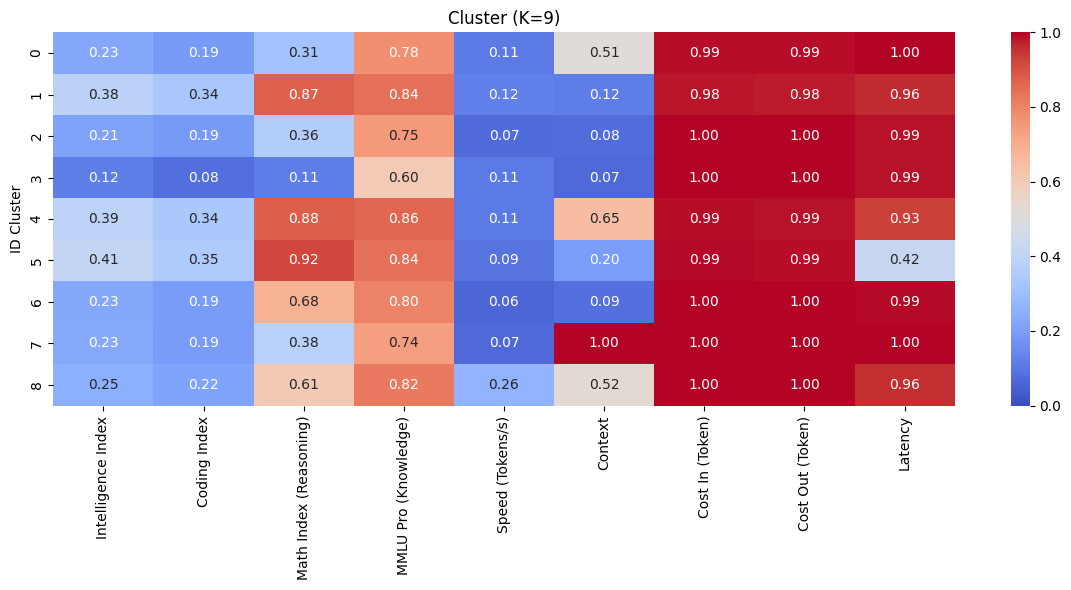


🏷️ ESEMPI DI MODELLI NEL CLUSTER 0:


,Link,Costo Input (1M Token) $,Intelligence Index
10,https://openrouter.ai/amazon/nova-premier-v1,2.50,0.190
28,https://openrouter.ai/anthropic/claude-sonnet-4,3.00,0.330
31,https://openrouter.ai/anthropic/claude-sonnet-4.5,3.00,0.371
69,https://openrouter.ai/google/gemini-2.5-flash-...,0.10,0.127
103,https://openrouter.ai/meta-llama/llama-4-maverick,0.15,0.184
163,https://openrouter.ai/openai/gpt-4.1,2.00,0.263
164,https://openrouter.ai/openai/gpt-4.1-mini,0.40,0.229
165,https://openrouter.ai/openai/gpt-4.1-nano,0.10,0.130



🏷️ ESEMPI DI MODELLI NEL CLUSTER 1:


,Link,Costo Input (1M Token) $,Intelligence Index
17,https://openrouter.ai/anthropic/claude-haiku-4.5,1.000,0.371
20,https://openrouter.ai/anthropic/claude-opus-4,15.000,0.390
21,https://openrouter.ai/anthropic/claude-opus-4.1,15.000,0.420
23,https://openrouter.ai/anthropic/claude-opus-4.5,5.000,0.431
24,https://openrouter.ai/anthropic/claude-opus-4.5,5.000,0.497
109,https://openrouter.ai/minimax/minimax-m2,0.255,0.361
111,https://openrouter.ai/minimax/minimax-m2.1,0.290,0.394
138,https://openrouter.ai/moonshotai/kimi-k2,0.570,0.409
176,https://openrouter.ai/openai/gpt-5-codex,1.250,0.446
180,https://openrouter.ai/openai/gpt-5.1,1.250,0.477



🏷️ ESEMPI DI MODELLI NEL CLUSTER 2:


...

,Link,Costo Input (1M Token) $,Intelligence Index
55,https://openrouter.ai/deepseek/deepseek-r1-dis...,0.700,0.160
137,https://openrouter.ai/moonshotai/kimi-k2,0.570,0.263
139,https://openrouter.ai/moonshotai/kimi-k2-0905,0.400,0.309
241,https://openrouter.ai/qwen/qwen3-max,0.780,0.261
245,https://openrouter.ai/qwen/qwen3-next-80b-a3b-...,0.090,0.201
247,https://openrouter.ai/qwen/qwen3-vl-235b-a22b-...,0.200,0.208
249,https://openrouter.ai/qwen/qwen3-vl-30b-a3b-in...,0.130,0.161
251,https://openrouter.ai/qwen/qwen3-vl-32b-instruct,0.104,0.172
280,https://openrouter.ai/x-ai/grok-3,3.000,0.252
292,https://openrouter.ai/xiaomi/mimo-v2-flash,0.090,0.304



🏷️ ESEMPI DI MODELLI NEL CLUSTER 7:


,Link,Costo Input (1M Token) $,Intelligence Index
287,https://openrouter.ai/x-ai/grok-4-fast,0.2,0.231
288,https://openrouter.ai/x-ai/grok-4.1-fast,0.2,0.236



🏷️ ESEMPI DI MODELLI NEL CLUSTER 8:


,Link,Costo Input (1M Token) $,Intelligence Index
66,https://openrouter.ai/google/gemini-2.5-flash,0.3,0.270
67,https://openrouter.ai/google/gemini-2.5-flash,0.3,0.206
68,https://openrouter.ai/google/gemini-2.5-flash-...,0.1,0.176
76,https://openrouter.ai/google/gemini-3-flash-pr...,0.5,0.350


In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

feature_cols = [
    'Intelligence Index', 'Coding Index', 'Math Index (Reasoning)', 'MMLU Pro (Knowledge)',
    'Norm_Speed', 'Norm_Context', 'Norm_Cost_In', 'Norm_Cost_Out', 'Norm_Latency'
]

df_clean = df.dropna(subset=feature_cols).copy()

X = df_clean[feature_cols]

K = 9

kmeans = KMeans(n_clusters=K, random_state=42, n_init='auto')
df_clean['Cluster_ID'] = kmeans.fit_predict(X)

df['Cluster_ID'] = np.nan
df.update(df_clean[['Cluster_ID']])

cluster_profiles = df_clean.groupby('Cluster_ID')[feature_cols].mean()

new_names = [
    'Intelligence Index', 'Coding Index', 'Math Index (Reasoning)', 'MMLU Pro (Knowledge)',
    'Speed (Tokens/s)', 'Context', 'Cost In (Token)', 'Cost Out (Token)', 'Latency'
]
cluster_profiles.columns = new_names

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title(f"Cluster (K={K})")
plt.ylabel("ID Cluster")
plt.tight_layout()
plt.show()

for i in range(K):
    print(f"\n🏷️ ESEMPI DI MODELLI NEL CLUSTER {i}:")
    modelli_cluster = df_clean[df_clean['Cluster_ID'] == i]
    colonna_nome = 'Link' if 'Link' in modelli_cluster.columns else modelli_cluster.columns[0]
    display(modelli_cluster[[colonna_nome, 'Costo Input (1M Token) $', 'Intelligence Index']].head(10))

In [28]:
from google.colab import output
output.enable_custom_widget_manager()

In [29]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

metriche = [
    'Costo Input (1M Token) $', 'Costo Output (1M Token) $', 'Latency (s)',
    'Speed (Tokens/s)', 'Intelligence Index', 'Coding Index',
    'Math Index (Reasoning)', 'MMLU Pro (Knowledge)', 'Context Window (Token)'
]

da_minimizzare = ['Costo Input (1M Token) $', 'Costo Output (1M Token) $', 'Latency (s)']

metriche_log = [
    'Costo Input (1M Token) $', 'Costo Output (1M Token) $',
    'Latency (s)', 'Speed (Tokens/s)', 'Context Window (Token)'
]

out_grafico = widgets.Output()

def aggiorna_grafico(asse_x, asse_y):
    with out_grafico:
        clear_output(wait=True)

        if asse_x == asse_y:
            print("Scegli due metriche diverse per gli assi X e Y.")
            return

        df_plot = df.copy()
        df_plot[asse_x] = pd.to_numeric(df_plot[asse_x], errors='coerce')
        df_plot[asse_y] = pd.to_numeric(df_plot[asse_y], errors='coerce')
        df_plot = df_plot.dropna(subset=[asse_x, asse_y])

        if df_plot.empty:
            print("Nessun dato disponibile per questa combinazione.")
            return

        min_x = asse_x in da_minimizzare
        min_y = asse_y in da_minimizzare

        df_plot = df_plot.sort_values(by=[asse_x, asse_y], ascending=[min_x, min_y])

        pareto_front = []
        best_y = float('inf') if min_y else float('-inf')

        for index, row in df_plot.iterrows():
            val_y = row[asse_y]
            is_better = (val_y < best_y) if min_y else (val_y > best_y)
            if is_better:
                pareto_front.append(row)
                best_y = val_y

        df_frontiera = pd.DataFrame(pareto_front)

        colonna_nome = 'Model Name (AA)' if 'Model Name (AA)' in df_plot.columns else 'Link'
        fig = px.scatter(
            df_plot,
            x=asse_x,
            y=asse_y,
            hover_name=colonna_nome,
            title=f"{asse_x} vs {asse_y}",
            template='plotly_white',
            height=600,
            opacity=0.6
        )

        if asse_x in metriche_log:
            fig.update_layout(xaxis_type="log")
        if asse_y in metriche_log:
            fig.update_layout(yaxis_type="log")

        if not df_frontiera.empty:
            df_frontiera = df_frontiera.sort_values(by=asse_x)
            fig.add_trace(
                go.Scatter(
                    x=df_frontiera[asse_x],
                    y=df_frontiera[asse_y],
                    mode='lines+markers',
                    line=dict(color='red', width=2, shape='hv'),
                    name='Optimal models',
                    marker=dict(size=8, color='red'),
                    hoverinfo='skip'
                )
            )

        fig_widget = go.FigureWidget(fig)
        display(fig_widget)

        print(f"{len(df_frontiera)} MODELLI CON MIGLIORE TRADE_OFF:")
        display(df_frontiera[[colonna_nome, asse_x, asse_y]].reset_index(drop=True))

dropdown_x = widgets.Dropdown(options=metriche, value='Costo Input (1M Token) $', description='Asse X:')
dropdown_y = widgets.Dropdown(options=metriche, value='Intelligence Index', description='Asse Y:')

def on_menu_change(change):
    aggiorna_grafico(dropdown_x.value, dropdown_y.value)

dropdown_x.observe(on_menu_change, names='value')
dropdown_y.observe(on_menu_change, names='value')

menu_box = widgets.HBox([dropdown_x, dropdown_y])
display(menu_box)
display(out_grafico)

aggiorna_grafico(dropdown_x.value, dropdown_y.value)

Output()